In [3]:
from google.colab import files
uploaded = files.upload()

Saving df_clean.csv to df_clean.csv


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

df = pd.read_csv('df_clean.csv')

y = (df['SI'] > df['SI'].median()).astype(int)
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y.value_counts())


SI
0    501
1    500
Name: count, dtype: int64


In [5]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
prob = lr.predict_proba(X_test)[:,1]
print('LogisticRegression Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


LogisticRegression Accuracy: 0.537 F1: 0.0 ROC-AUC: 0.537


In [6]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:,1]
print('RandomForest Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


RandomForest Accuracy: 0.677 F1: 0.649 ROC-AUC: 0.721


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
prob = gb.predict_proba(X_test)[:,1]
print('GradientBoosting Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))



GradientBoosting Accuracy: 0.672 F1: 0.641 ROC-AUC: 0.721


In [8]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
prob = xgb.predict_proba(X_test)[:,1]
print('XGBoost Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


XGBoost Accuracy: 0.677 F1: 0.652 ROC-AUC: 0.733


In [9]:
from sklearn.model_selection import GridSearchCV

param_xgb = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}

grid_xgb = GridSearchCV(XGBClassifier(random_state=42), param_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(grid_xgb.best_params_)
pred = grid_xgb.predict(X_test)
prob = grid_xgb.predict_proba(X_test)[:,1]
print('XGB tuned ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGB tuned ROC-AUC: 0.724


In [10]:
param_rf = {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
pred = grid_rf.predict(X_test)
prob = grid_rf.predict_proba(X_test)[:,1]
print('RF tuned ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
RF tuned ROC-AUC: 0.728


SI сложнее предсказывать чем CC50. Лучшая модель RF с max_depth=5, ROC-AUC=0.728. XGBoost немного хуже.

Pipeline с отбором 50 лучших признаков. У SI признаки слабо связаны с таргетом, поэтому интересно проверить помогает ли отбор признаков улучшить результат по сравнению с RF tuned на всех признаках.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

pipe = Pipeline([
    ('var', VarianceThreshold()),
    ('select', SelectKBest(f_classif, k=50)),
    ('clf', RandomForestClassifier(random_state=42))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:, 1]
print('Pipeline ROC-AUC:', round(roc_auc_score(y_test, prob), 3))
print('Pipeline F1:     ', round(f1_score(y_test, pred), 3))

Pipeline ROC-AUC: 0.722
Pipeline F1:      0.634


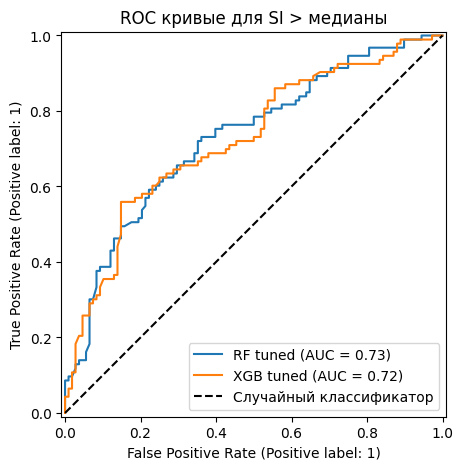

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(grid_rf, X_test, y_test, ax=ax, name='RF tuned')
RocCurveDisplay.from_estimator(grid_xgb, X_test, y_test, ax=ax, name='XGB tuned')
ax.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
ax.set_title('ROC кривые для SI > медианы')
ax.legend()
plt.show()

Pipeline с отбором 50 лучших признаков дал ROC-AUC=0.722, что чуть хуже RF tuned на всех признаках (0.728). Значит часть полезной информации теряется при сокращении до 50 признаков. Для SI лучше использовать все признаки.